# Forecasting power demand in Lithuania

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

In [26]:
bad_encoding = ['2021-01', '2021-02', '2021-04', '2021-05', '2021-06', '2021-07', '2021-08', '2021-09', '2021-10', '2021-11', '2021-12']

In [27]:
dfs = []
for filename in bad_encoding:
    filename = f"{filename}.csv"
    dfs.append(pd.read_csv(f"./data/{filename}", sep=';', encoding='ISO-8859-1', decimal=','))

power = pd.concat(dfs, ignore_index=True)

In [28]:
dfs = [power]

dfs.append(pd.read_csv("./data/2021-03.csv"))

for year in range(2022, 2025):
    for month in range(1, 13):
        filename = f"{year}-{month:02d}.csv"
        path = f"./data/{filename}"

        if filename in ['2022-01.csv', '2022-02.csv', '2022-03.csv']:
            dfs.append(pd.read_csv(path, sep=';', decimal=','))
        elif not (year == 2024 and month > 7):
            dfs.append(pd.read_csv(path))

power = pd.concat(dfs, ignore_index=True)

In [29]:
power.PL_T = power.PL_T.str.replace('.000', '')

power.PL_T = pd.to_datetime(power.PL_T)

In [30]:
power.sort_values(by='PL_T', ascending=True)

,GR_NAME,PL_T,P+,OBJ_COUNT
0,Akmenës Vartotojai,2021-01-01 00:00:00,1.0929,3
744,Alytaus Vartotojai,2021-01-01 00:00:00,188.4825,742
29757,Zarasø Vartotojai,2021-01-01 00:00:00,5.6093,5
14877,Maþeikiø Vartotojai,2021-01-01 00:00:00,3.4560,4
15621,Molëtø Vartotojai,2021-01-01 00:00:00,9.0789,15
...,...,...,...,...
1366217,Vilniaus rajono Vartotojai,2024-07-31 23:00:00,0.1405,3
1366961,Šakių Vartotojai,2024-07-31 23:00:00,0.0000,1
1363229,Panevėžio Vartotojai,2024-07-31 23:00:00,0.2228,1
1365473,Vilniaus miesto Vartotojai,2024-07-31 23:00:00,14.7827,9


In [31]:
power.PL_T.unique()

<DatetimeArray>
['2021-01-01 00:00:00', '2021-01-01 01:00:00', '2021-01-01 02:00:00',
 '2021-01-01 03:00:00', '2021-01-01 04:00:00', '2021-01-01 05:00:00',
 '2021-01-01 06:00:00', '2021-01-01 07:00:00', '2021-01-01 08:00:00',
 '2021-01-01 09:00:00',
 ...
 '2024-07-31 14:00:00', '2024-07-31 15:00:00', '2024-07-31 16:00:00',
 '2024-07-31 17:00:00', '2024-07-31 18:00:00', '2024-07-31 19:00:00',
 '2024-07-31 20:00:00', '2024-07-31 21:00:00', '2024-07-31 22:00:00',
 '2024-07-31 23:00:00']
Length: 31392, dtype: datetime64[us]

In [32]:
power = power.reset_index(drop=True)

In [33]:
power = power.groupby('PL_T')['P+'].sum()

<Axes: xlabel='PL_T'>

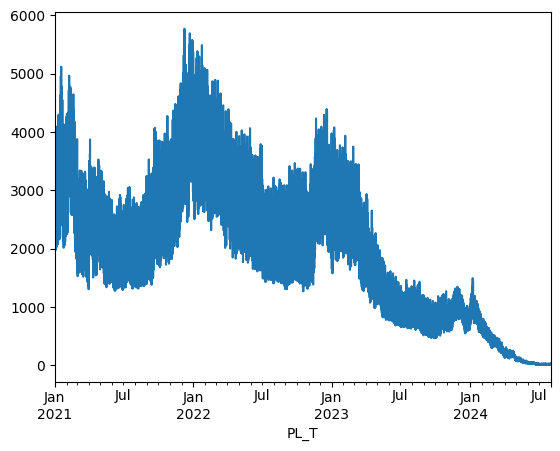

In [34]:
power.plot()